In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, roc_curve

plt.style.use('seaborn-v0_8')

print("Libraries loaded")

Libraries loaded


In [2]:
df = pd.read_csv('../data/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)

y_proba = xgb.predict_proba(X_test_scaled)[:, 1]

print("Model trained")
print(f"Test set: {len(y_test)} transactions, {sum(y_test)} fraud")

Model trained
Test set: 56962 transactions, 98 fraud


In [3]:
# cost matrix
FRAUD_AMOUNT = y_test[y_test == 1].index
avg_fraud_amount = df.loc[FRAUD_AMOUNT, 'Amount'].mean()

TP_VALUE = avg_fraud_amount  # saved money per caught fraud
FP_COST = 10                 # cost of blocking a legitimate transaction
FN_COST = avg_fraud_amount   # lost money per missed fraud

print(f"Average fraud amount: ${avg_fraud_amount:.2f}")
print(f"TP value (fraud caught): ${TP_VALUE:.2f}")
print(f"FP cost (legitimate blocked): ${FP_COST:.2f}")
print(f"FN cost (fraud missed): ${FN_COST:.2f}")

Average fraud amount: $108.62
TP value (fraud caught): $108.62
FP cost (legitimate blocked): $10.00
FN cost (fraud missed): $108.62


In [4]:
# threshold sweep
thresholds = np.linspace(0.1, 0.9, 100)
results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    
    TP = sum((y_pred == 1) & (y_test == 1))
    FP = sum((y_pred == 1) & (y_test == 0))
    FN = sum((y_pred == 0) & (y_test == 1))
    TN = sum((y_pred == 0) & (y_test == 0))
    
    saved_money = TP * TP_VALUE
    blocked_legit = FP
    lost_money = FN * FN_COST
    profit = saved_money - (FP * FP_COST) - lost_money
    
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    
    results.append({
        'threshold': threshold,
        'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
        'saved_money': saved_money,
        'blocked_legit': blocked_legit,
        'lost_money': lost_money,
        'profit': profit,
        'recall': recall,
        'precision': precision
    })

results_df = pd.DataFrame(results)
print(results_df.head())

   threshold  TP  FP  FN     TN  saved_money  blocked_legit   lost_money  \
0   0.100000  84  24  14  56840  9124.225714             24  1520.704286   
1   0.108081  84  23  14  56841  9124.225714             23  1520.704286   
2   0.116162  84  23  14  56841  9124.225714             23  1520.704286   
3   0.124242  84  22  14  56842  9124.225714             22  1520.704286   
4   0.132323  84  22  14  56842  9124.225714             22  1520.704286   

        profit    recall  precision  
0  7363.521429  0.857143   0.777778  
1  7373.521429  0.857143   0.785047  
2  7373.521429  0.857143   0.785047  
3  7383.521429  0.857143   0.792453  
4  7383.521429  0.857143   0.792453  


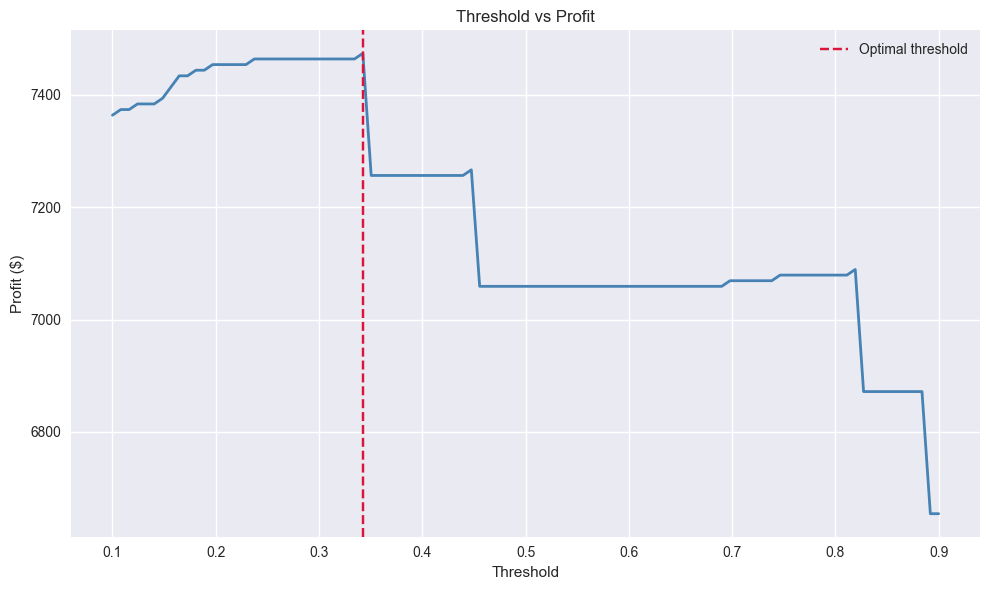

Optimal threshold: 0.342
Max profit: $7473.52


In [5]:
# Threshold vs Profit curve
plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['profit'], color='steelblue', linewidth=2)
plt.xlabel('Threshold')
plt.ylabel('Profit ($)')
plt.title('Threshold vs Profit')
plt.axvline(results_df.loc[results_df['profit'].idxmax(), 'threshold'], 
            color='crimson', linestyle='--', label='Optimal threshold')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/threshold_profit.png', dpi=150)
plt.show()

optimal = results_df.loc[results_df['profit'].idxmax()]
print(f"Optimal threshold: {optimal['threshold']:.3f}")
print(f"Max profit: ${optimal['profit']:.2f}")

In [ ]:
# scenario comparison
scenarios = {
    'Aggressive (0.3)': 0.3,
    'Balanced (0.5)': 0.5,
    'Conservative (0.7)': 0.7
}

print(f"{'Scenario':<25} {'Recall':<10} {'Precision':<12} {'Saved $':<12} {'Blocked Legit':<15} {'Profit'}")
print("-" * 85)

for name, threshold in scenarios.items():
    row = results_df[results_df['threshold'].between(threshold - 0.01, threshold + 0.01)].iloc[0]
    print(f"{name:<25} {row['recall']:<10.2f} {row['precision']:<12.2f} ${row['saved_money']:<11.2f} {int(row['blocked_legit']):<15} ${row['profit']:.2f}")